In [1]:
import os, sys, importlib
import json
import pandas as pd

## merge

In [2]:
import pandas as pd

df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")
print(len(df_all))

RESULTS_FOLDER="results"
IMAGES_FOLDER='images'
path_result_london=os.path.join(RESULTS_FOLDER,f"deepface_results_london.json")
path_result_paris=os.path.join(RESULTS_FOLDER,f"deepface_results_paris.json")

with open(path_result_london, 'r', encoding='utf-8')as f:
    results_london=json.load(f)
    print(len(results_london))
with open(path_result_paris, 'r', encoding='utf-8')as f:
    results_paris=json.load(f)
    print(len(results_paris))

C:\Users\yeliu\AppData\Local\Temp\ipykernel_13780\21929727.py:3: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")


112594
24819
43055


In [13]:
results=[]
results.extend(results_london)
results.extend(results_paris)
print(len(results))
print(results[0])

df_results=pd.DataFrame(results)
print(df_results.columns)
df_results_to_merge=df_results[['host_id','host_picture_type',"age_class",'gender','is_smiling']]
display(df_results_to_merge.head())

67874
{'img_path': '/content/drive/MyDrive/airbnbMM2/host_pic/images/host_pic_london_25051/10005361.jpg', 'host_id': 10005361, 'has_face': 0, 'nb_face': 0, 'face_area_ratio': 0, 'avg_face_prob': 0, 'bbox_list': [], 'clean_score': 0, 'lifestyle_score': 0, 'host_picture_type': 'no_person', 'age': 'unk', 'age_class': 'unk', 'gender': 'unk', 'smile_score': 0, 'is_smiling': 0, 'dominant_emotion': None}
Index(['img_path', 'host_id', 'has_face', 'nb_face', 'face_area_ratio',
       'avg_face_prob', 'bbox_list', 'clean_score', 'lifestyle_score',
       'host_picture_type', 'age', 'age_class', 'gender', 'smile_score',
       'is_smiling', 'dominant_emotion'],
      dtype='object')


,host_id,host_picture_type,age_class,gender,is_smiling
0,10005361,no_person,unk,unk,0
1,100076439,no_person,unk,unk,0
2,100079118,pro_style,middle,Woman,1
3,10008184,no_person,unk,unk,0
4,100068787,pro_style,middle,Man,0


In [14]:
df_all_pic=df_all.merge(df_results_to_merge, left_on="host_id", right_on="host_id", how='left')
print(df_all_pic[['host_id','city','host_picture_type']])

          host_id    city host_picture_type
0            3631   paris        life_style
1          433758   paris         no_person
2            7903   paris        life_style
3            2626   paris         pro_style
4          228508   paris         pro_style
...           ...     ...               ...
112589  506745061  london               NaN
112590  576355034  london               NaN
112591  218825499  london         pro_style
112592  132802067  london         pro_style
112593  509027540  london               NaN

[112594 rows x 3 columns]


In [16]:
# df_all_pic.to_csv("../data_all\listings_paris_london2406_pic2.csv", index=False)

## quick modeling

In [ ]:
import pandas as pd

path_csv="../data_all\listings_paris_london2406_pic2.csv"
df_all_pic=pd.read_csv(path_csv)

In [17]:
df_all_pic_fillna=df_all_pic.copy()
df_all_pic_fillna['host_picture_type']=df_all_pic['host_picture_type'].fillna('no_person')
print(df_all_pic_fillna['host_picture_type'].value_counts(dropna=False)/len(df_all_pic))


host_picture_type
pro_style     0.359895
no_person     0.343811
life_style    0.296295
Name: count, dtype: float64


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(roo

,city,ouverture,is_base,coef,se,t,pval,sig
0,paris,1,False,-0.003971,0.001294,-3.069630,0.002144,**
1,london,1,True,0.001828,0.001260,1.450221,0.147000,


authenticité


,city,authenticité,is_base,coef,se,t,pval,sig
0,paris,1,False,0.001293,0.001439,0.898464,0.368940,
1,london,1,True,0.004257,0.001402,3.036273,0.002396,**


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + age_class + gender + is_smiling



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + age_class + gender + is_smiling



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:920: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


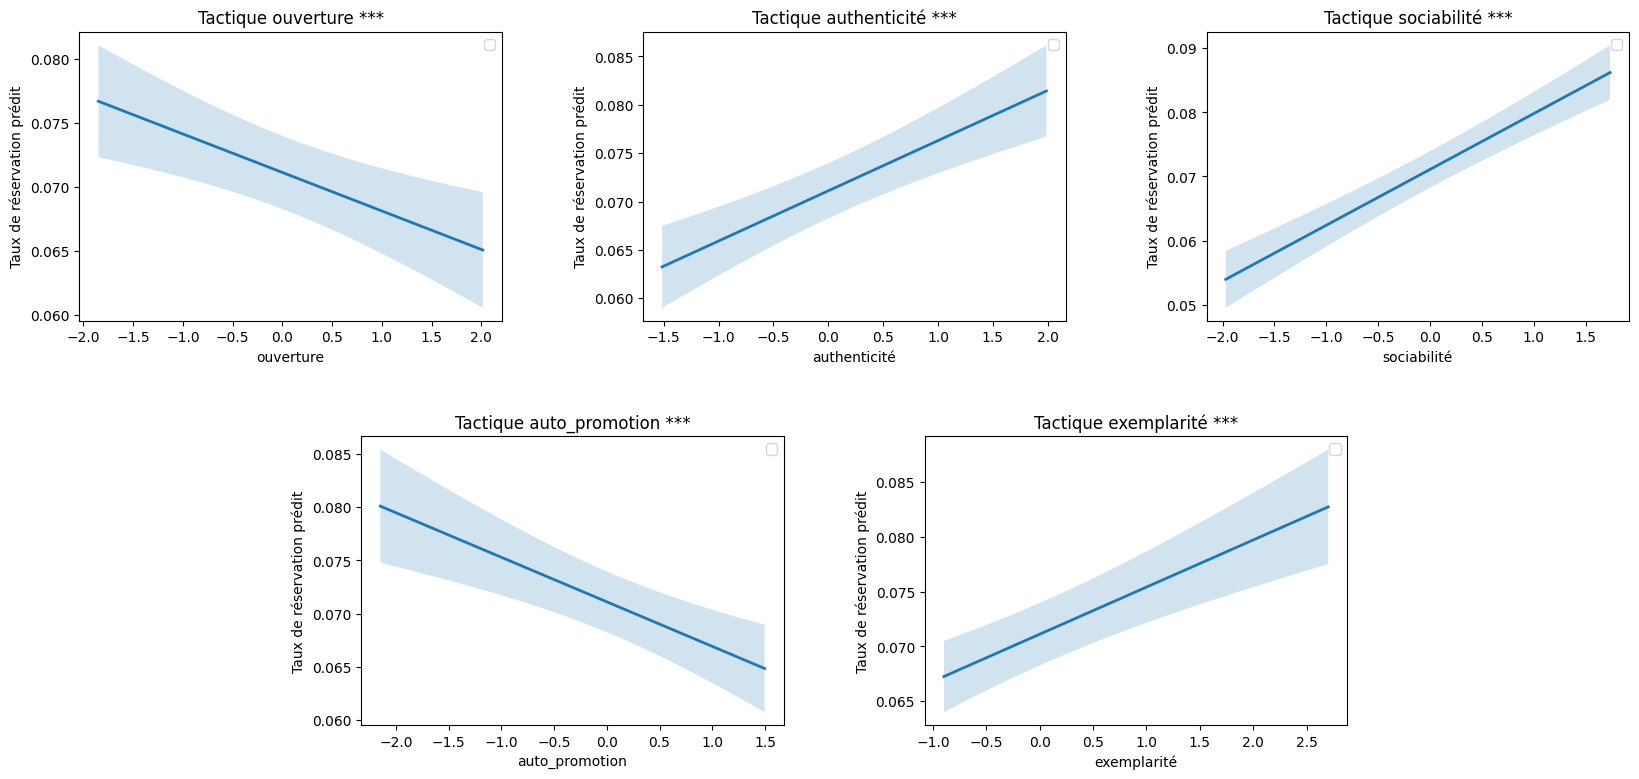

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['city']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(city)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + age_class + gender + is_smiling + C(city)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité + host_picture_type + age_class + gender + is_smiling)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture +

In [ ]:
import os, sys, importlib
sys.path.append(os.path.abspath(".."))
import pandas as pd
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',"is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
    # "host_picture_type"
]  
# tactics_vars=["personality","quality","host_picture_type"]

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              "host_picture_type","age_class",'gender','is_smiling'
              ]

modeling_main(df_input=df_all_pic_fillna, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="city",
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )